In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# STEP 1: LOAD SIMULATION OUTPUT
# ============================================================

file_path = "../bin/anode_concentrations.txt"

with open(file_path, 'r') as f:
    lines = f.readlines()
    #read lines starting at line 102:
    lines = lines[27:]

pattern = re.compile(
    r"timestep:\s*(\d+).*?VCell\s*=\s*([-eE0-9.]+),.*?XfrC_avg\s*=\s*([-eE0-9.]+)"
)

data = []

for line in lines:
    match = pattern.search(line)
    if match:
        timestep = int(match.group(1))
        XfrC = float(match.group(3))
        vcell = abs(float(match.group(2)))

        data.append((timestep, vcell, XfrC))

df = pd.DataFrame(data, columns=["timestep", "vcell", "XfrC"])

# Optional filtering
# df = df[df["timestep"] % 500 != 0]
# df = df[df["timestep"] != 0]

# ============================================================
# STEP 2: LOAD LFP OCV TABLE
# ============================================================

ticks = np.loadtxt("../inputs/materials/C_Li_X_101.txt")
ocv = np.loadtxt("../inputs/materials/C_Li_O3_101.txt")

# Convert chemical potential to OCV
# ocv = -mu + 3.4

# ============================================================
# STEP 3: INTERPOLATE OCV AT SIMULATION XfrC VALUES
# ============================================================

df["ocv"] = np.interp(df["XfrC"], ticks, ocv)

# ============================================================
# STEP 4: PLOT
# ============================================================

plt.figure(figsize=(10,6))

# Simulation voltage
plt.plot(
    df["XfrC"],
    df["vcell"],
    linewidth=2,
    label="Simulation VCell"
)

# OCV curve
plt.plot(
    ticks,
    ocv,
    '--',
    linewidth=2,
    label="OCV"
)

# Optional: interpolated OCV sampled at simulation points
# plt.plot(df["XfrC"], df["ocv"], 'o', markersize=3)

plt.xlabel("XfrC")
plt.ylabel("Voltage (V)")
plt.title("VCell vs XfrC with OCV")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

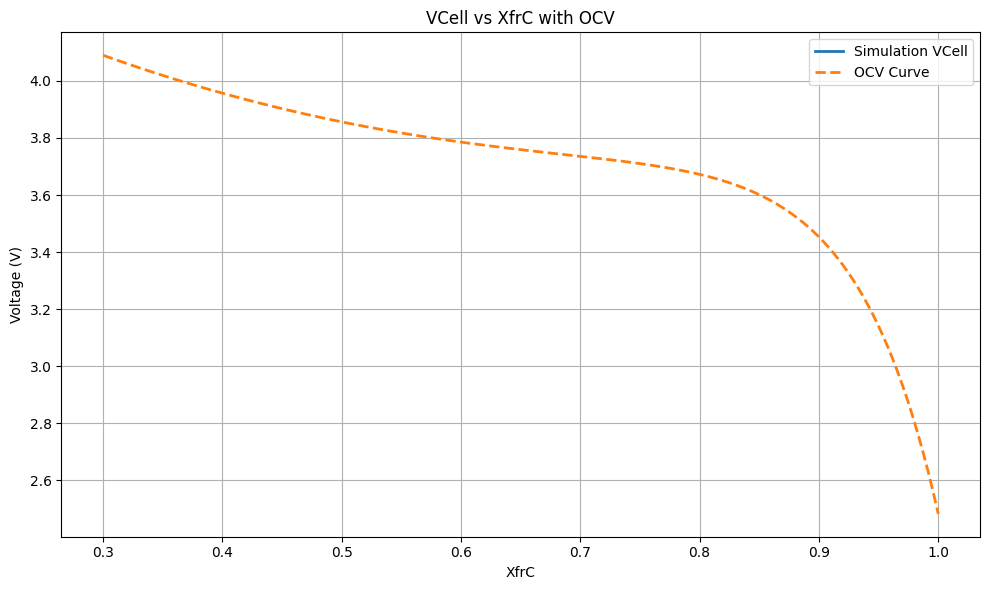

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# STEP 1: LOAD SIMULATION OUTPUT
# ============================================================

file_path = "../bin/cathode_concentrations.txt"

# with open(file_path, 'r') as f:
#     lines = f.readlines()

with open(file_path, 'r') as f:
    lines = f.readlines()[7:]   # start at line 87

pattern = re.compile(
    r"timestep:\s*(\d+).*?VCell\s*=\s*([-eE0-9.]+),.*?XfrC_avg\s*=\s*([-eE0-9.]+)"
)

data = []

for line in lines:
    match = pattern.search(line)
    if match:
        timestep = int(match.group(1))
        XfrC = float(match.group(3))
        vcell = abs(float(match.group(2)))

        data.append((timestep, vcell, XfrC))

df = pd.DataFrame(data, columns=["timestep", "vcell", "XfrC"])

# Optional filtering
# df = df[df["timestep"] % 500 != 0]
# df = df[df["timestep"] != 0]

# ============================================================
# STEP 2: DEFINE OCV FUNCTION
# ============================================================

def ocv_function(c):
    return (
        1.095 * c * c
        - 8.234e-7 * np.exp(14.31 * c)
        + 4.692 * np.exp(-0.5389 * c)
    )

# Generate smooth OCV curve
c_vals = np.linspace(0.3, 1.0, 500)
ocv_vals = ocv_function(c_vals)

# Interpolated OCV at simulation points
df["ocv"] = ocv_function(df["XfrC"])

# ============================================================
# STEP 3: PLOT
# ============================================================

plt.figure(figsize=(10,6))

# Simulation voltage
plt.plot(
    df["XfrC"],
    df["vcell"],
    linewidth=2,
    label="Simulation VCell"
)

# Analytical OCV curve
plt.plot(
    c_vals,
    ocv_vals,
    '--',
    linewidth=2,
    label="OCV Curve"
)

plt.xlabel("XfrC")
plt.ylabel("Voltage (V)")
plt.title("VCell vs XfrC with OCV")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

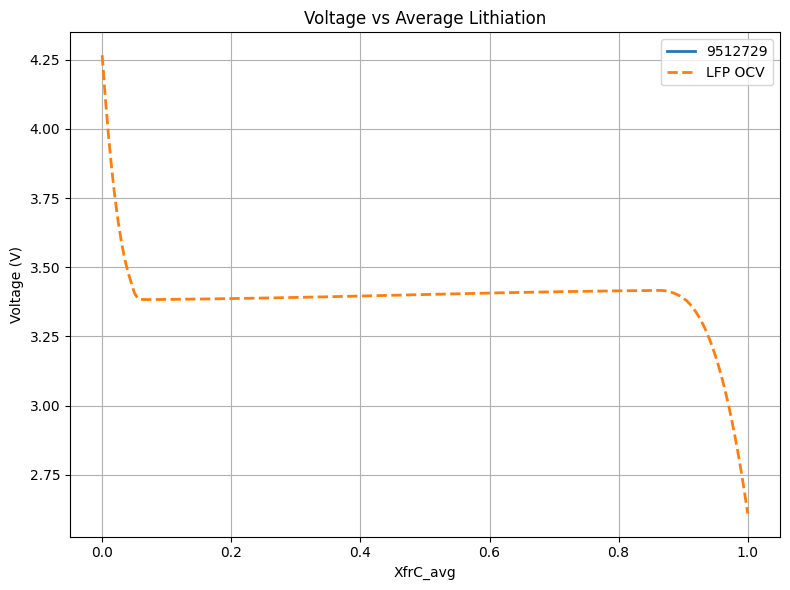

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PARSER
# ============================================================

# pattern = re.compile(
#     r"timestep:\s*\d+\s*\[.*?\],\s*VCell\s*=\s*([-eE0-9.]+).*?XfrC_avg\s*=\s*([-eE0-9.]+)"
# )

pattern = re.compile(
    r"VCell\s*=\s*([-eE0-9.]+).*?XfrC_avg\s*=\s*([-eE0-9.]+)"
)

def load_data(file_path):
    data = []

    with open(file_path, 'r') as f:
        for line in f:
            match = pattern.search(line)

            if match:
                vcell = float(match.group(1))
                xfrc = float(match.group(2))

                data.append((xfrc, vcell))

    return pd.DataFrame(data, columns=["XfrC_avg", "VCell"])

# ============================================================
# LOAD FILES
# ============================================================

df1 = load_data(
    "../MSU_HPCC/slurm_besfem-config-tiff-3.0-9512729.SLURMout"
)

# df2 = load_data(
#     "../MSU_HPCC/slurm_besfem-config-tiff-9155931.SLURMout"
# )

# ============================================================
# LOAD AND CALCULATE LFP OCV
# ============================================================

ticks = np.loadtxt("../inputs/materials/LFP_Chm_Pot_Ticks.txt")
chmPot = np.loadtxt("../inputs/materials/LFP_Chm_Pot.txt")

# Matches MaterialProperties.cpp:
# OCV = -chemical_potential + 3.4
ocv = -chmPot + 3.4

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(8,6))

plt.plot(
    df1["XfrC_avg"],
    df1["VCell"],
    linewidth=2,
    label="9512729"
)

# plt.plot(
#     df2["XfrC_avg"],
#     df2["VCell"],
#     linewidth=2,
#     label="9155931"
# )

plt.plot(
    ticks,
    ocv,
    "--",
    linewidth=2,
    label="LFP OCV"
)

plt.xlabel("XfrC_avg")
plt.ylabel("Voltage (V)")
plt.title("Voltage vs Average Lithiation")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

../MSU_HPCC/slurm_besfem-6.38e-16-4hrs-mob1e-13-NEW-12331508.SLURMout
Points found: 1
   XfrC_avg  VCell  Cp_min  Cp_max
0     0.052  3.396   0.052   0.052


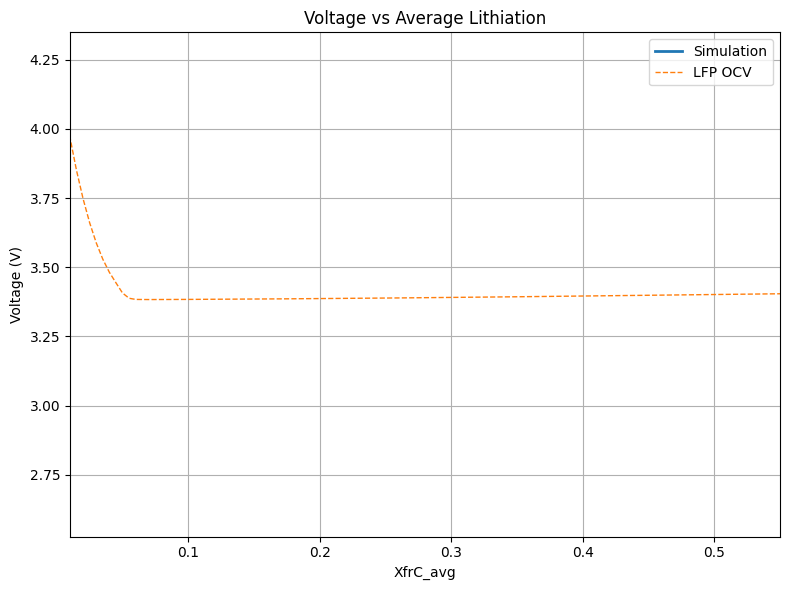

In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PARSER
# ============================================================

pattern = re.compile(
    r"timestep:\s*\d+\s*\[.*?\],\s*VCell\s*=\s*([-+eE0-9.]+).*?"
    r"Cp_min\s*=\s*([-+eE0-9.]+).*?"
    r"Cp_max\s*=\s*([-+eE0-9.]+).*?"
    r"XfrC_avg\s*=\s*([-+eE0-9.]+)",
    re.DOTALL
)

def load_data(file_path):
    with open(file_path, "r") as f:
        text = f.read()

    matches = pattern.findall(text)

    data = []
    for vcell, cp_min, cp_max, xfrc in matches:
        data.append((
            float(xfrc),
            float(vcell),
            float(cp_min),
            float(cp_max)
        ))

    df = pd.DataFrame(
        data,
        columns=["XfrC_avg", "VCell", "Cp_min", "Cp_max"]
    )

    print(f"{file_path}")
    print(f"Points found: {len(df)}")
    print(df.head())

    return df

# ============================================================
# LOAD FILES
# ============================================================

df1 = load_data(
    "../MSU_HPCC/slurm_besfem-6.38e-16-4hrs-mob1e-13-NEW-12331508.SLURMout"
)

# ============================================================
# LOAD AND CALCULATE LFP OCV
# ============================================================

ticks = np.loadtxt("../inputs/materials/LFP_Chm_Pot_Ticks.txt")
chmPot = np.loadtxt("../inputs/materials/LFP_Chm_Pot.txt")

# Matches MaterialProperties.cpp:
# OCV = -chemical_potential + 3.4
ocv = -chmPot + 3.4

# ============================================================
# PLOT 1: VOLTAGE VS AVERAGE LITHIATION
# ============================================================

plt.figure(figsize=(8, 6))

plt.plot(
    df1["XfrC_avg"],
    df1["VCell"],
    linewidth=2,
    label="Simulation"
)

plt.plot(
    ticks,
    ocv,
    "--",
    linewidth=1,
    label="LFP OCV"
)

plt.xlabel("XfrC_avg")
plt.ylabel("Voltage (V)")
plt.xlim(0.01, 0.55)
# plt.ylim(3.2, 3.5)
plt.title("Voltage vs Average Lithiation")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# # ============================================================
# # PLOT 2: Cp_min AND Cp_max VS AVERAGE LITHIATION
# # ============================================================

# plt.figure(figsize=(8, 6))

# plt.plot(
#     df1["XfrC_avg"],
#     df1["Cp_min"],
#     linewidth=2,
#     label="Cp_min"
# )

# plt.plot(
#     df1["XfrC_avg"],
#     df1["Cp_max"],
#     linewidth=2,
#     label="Cp_max"
# )

# plt.plot(
#     df1["XfrC_avg"],
#     df1["XfrC_avg"],
#     "--",
#     linewidth=2,
#     label="XfrC_avg"
# )

# plt.xlabel("XfrC_avg")
# plt.ylabel("Concentration")
# plt.title("LFP Concentration Spread")
# plt.grid(True)
# plt.legend()
# plt.tight_layout()
# plt.show()